In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv


## import libraries

In [2]:
import os
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
# Dataset Configuration
DATA_PATH = "/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv"

TOP_MOVIES = 8000
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_N = 10

In [5]:
# Recommendation System Parameters
MIN_VOTE_COUNT = 50
MIN_INTERACTIONS_WARM = 5
TEST_HOLDOUT_FRAC = 0.2

N_SYNTHETIC_USERS = 6000
INTERACTIONS_PER_USER = (5, 40)
N_NEGATIVES = 99

In [6]:
# Create Artifact Directory
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [7]:
# Device Configuration (CPU/GPU)
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


## Load data with synthetic fallback

In [8]:
# Function to Generate Synthetic Movie Dataset
def generate_synthetic_movies(n=3000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)

    genre_pool = [
        "Action", "Comedy", "Drama", "Horror", "Romance", "Sci-Fi",
        "Thriller", "Animation", "Documentary", "Fantasy",
        "Crime", "Adventure"
    ]

    keyword_pool = [
        "heist", "space", "friendship", "revenge", "coming-of-age",
        "detective", "monster", "war", "family", "time travel",
        "underdog", "betrayal", "survival", "magic", "robot"
    ]

    language_pool = [
        "English", "Spanish", "French",
        "Japanese", "Korean", "Hindi"
    ]

    country_pool = [
        "United States", "United Kingdom", "France",
        "Japan", "South Korea", "India"
    ]

    rows = []

    for i in range(n):
        n_genres = rng.integers(1, 3)
        genres = rng.choice(genre_pool, size=n_genres, replace=False)

        n_keywords = rng.integers(2, 5)
        keywords = rng.choice(keyword_pool, size=n_keywords, replace=False)

        vote_count = int(rng.pareto(1.5) * 50)
        vote_average = float(np.clip(rng.normal(6.2, 1.1), 1, 10))

        rows.append({
            "id": i,
            "title": f"Movie {i:04d}",
            "genres": ",".join(genres),
            "keywords": ",".join(keywords),
            "overview": f"A story about {' and '.join(keywords[:2])} involving {genres[0].lower()} elements.",
            "tagline": f"{genres[0]} like never before.",
            "spoken_languages": rng.choice(language_pool),
            "production_countries": rng.choice(country_pool),
            "vote_average": round(vote_average, 1),
            "vote_count": vote_count,
        })

    return pd.DataFrame(rows)

In [9]:
# load dataset
if os.path.exists(DATA_PATH):
    print("Loading real TMDB dataset...")
    raw = pd.read_csv(DATA_PATH)
    USING_SYNTHETIC = False
else:
    print("Real dataset not found at DATA_PATH.")
    print("Generating synthetic movie catalog for demonstration...")
    raw = generate_synthetic_movies()
    USING_SYNTHETIC = True

Loading real TMDB dataset...


In [10]:
# preprocess movie data
df = (
    raw.sort_values(by="vote_count", ascending=False)
       .drop_duplicates(subset="id", keep="first")
       .head(TOP_MOVIES)
       .reset_index(drop=True)
)

In [11]:
df["movie_idx"] = df.index

In [12]:
# Verify dataset
print(f"Movies kept: {len(df):,}")
df.head()

Movies kept: 8,000


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,movie_idx
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",3
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",4


## feature engineering & text preprocessing

In [13]:
# Handle Missing Values & Data Types
text_cols = [
    "overview",
    "genres",
    "keywords",
    "tagline",
    "spoken_languages",
    "production_countries"
]

# Fill missing text values
df[text_cols] = df[text_cols].fillna("")

# Convert numeric columns
df["vote_count"] = pd.to_numeric(df["vote_count"], errors="coerce").fillna(0)
df["vote_average"] = (
    pd.to_numeric(df["vote_average"], errors="coerce")
      .fillna(df["vote_average"].median())
)

In [14]:
# Create Structured Movie Text
def build_structured_tags(row):
    genres = " ".join(
        f"genre_{g.strip().replace(' ', '_')}"
        for g in row["genres"].split(",")
        if g.strip()
    )

    countries = " ".join(
        f"country_{c.strip().replace(' ', '_')}"
        for c in row["production_countries"].split(",")
        if c.strip()
    )

    languages = " ".join(
        f"lang_{l.strip().replace(' ', '_')}"
        for l in row["spoken_languages"].split(",")
        if l.strip()
    )

    keywords = " ".join(
        f"kw_{k.strip().replace(' ', '_')}"
        for k in row["keywords"].split(",")
        if k.strip()
    )

    return (
        f"{row['overview']} "
        f"{genres} "
        f"{countries} "
        f"{languages} "
        f"{keywords} "
        f"{row['tagline']}"
    )

In [15]:
# Generate Structured Text
df["structured_text"] = df.apply(build_structured_tags, axis=1)

In [16]:
# Import & Download NLTK Resources
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [17]:
# Text Preprocessing Function
def preprocess_text(text):
    text = str(text).lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9_\s]", "", text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [18]:
# Preprocess Movie Text
df["processed_tags"] = df["structured_text"].apply(preprocess_text)

In [19]:
# Create Genre List
df["genre_list"] = df["genres"].apply(
    lambda g: [genre.strip() for genre in g.split(",") if genre.strip()]
)

In [20]:
# Verify Processed Data
print(df[["title", "processed_tags"]].head(2))

          title                                     processed_tags
0     Inception  cobb skilled thief commits corporate espionage...
1  Interstellar  adventure group explorer make use newly discov...


## Content embeddings + FAISS index

In [21]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 88.3 MB/s eta 0:00:00:00:010:01


In [22]:
# Load Sentence Transformer Model
from sentence_transformers import SentenceTransformer
import faiss
embed_model = SentenceTransformer(
    EMBED_MODEL_NAME,
    device=DEVICE
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [23]:
embeddings = embed_model.encode(
    df["processed_tags"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [24]:
# Build FAISS Index & Save Embeddings
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

np.save(
    os.path.join(ARTIFACT_DIR, "movie_embeddings.npy"),
    embeddings
)

print(f"FAISS index: {index.ntotal} vectors of dim {dimension}")

FAISS index: 8000 vectors of dim 384


## Popularity baseline

In [25]:
# Calculate IMDb Weighted Rating
C = df["vote_average"].mean()
m = MIN_VOTE_COUNT

df["weighted_score"] = (
    (df["vote_count"] / (df["vote_count"] + m)) * df["vote_average"]
    + (m / (df["vote_count"] + m)) * C
)

In [26]:
# Normalize Popularity Score
df["norm_weighted_score"] = (
    df["weighted_score"] / df["weighted_score"].max()
)

In [27]:
# Popularity ranking function
def popularity_score_candidates(user_id, candidates):
    sub = df[df["movie_idx"].isin(candidates)]

    return (
        sub.sort_values("weighted_score", ascending=False)["movie_idx"]
        .tolist()
    )

In [28]:
# Display Top Popular Movies
df.sort_values(
    "weighted_score",
    ascending=False
).head(5)[
    ["title", "vote_average", "vote_count", "weighted_score"]
]

,title,vote_average,vote_count,weighted_score
53,The Godfather,8.707,18677,8.701551
14,The Shawshank Redemption,8.702,24649,8.697879
215,The Godfather Part II,8.591,11293,8.582516
119,Schindler's List,8.573,14594,8.566490
107,Spirited Away,8.539,14913,8.532742


## Simulate User interactions + onboarding genre profiles

In [29]:
# Helper function
def _genre_set(genre_list):
    return set(genre_list)

In [30]:
# Generate Sysnthetic user interactions
def generate_synthetic_interactions(
    df,
    n_users=N_SYNTHETIC_USERS,
    interactions_range=INTERACTIONS_PER_USER,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)

    all_genres = sorted(
        set(genre for genres in df["genre_list"] for genre in genres)
    )

    records = []
    user_profiles = {}

    for user_id in range(n_users):

        # Assign favorite genres
        n_fav = rng.integers(1, 3)
        fav_genres = set(
            rng.choice(
                all_genres,
                size=min(n_fav, len(all_genres)),
                replace=False,
            )
        )

        user_profiles[user_id] = fav_genres

        # Number of interactions
        n_interactions = rng.integers(
            interactions_range[0],
            interactions_range[1] + 1,
        )

        # Prefer movies matching favorite genres
        match_mask = df["genre_list"].apply(
            lambda genres: bool(fav_genres & _genre_set(genres))
        )

        weights = np.where(match_mask, 9.0, 1.0)
        weights = weights / weights.sum()

        chosen_movies = rng.choice(
            df.index.values,
            size=min(n_interactions, len(df)),
            replace=False,
            p=weights,
        )

        # Generate ratings
        for movie_idx in chosen_movies:

            base_rating = 4.5 if match_mask.loc[movie_idx] else 1.8

            rating = float(
                np.clip(
                    rng.normal(base_rating, 0.6),
                    1,
                    5,
                )
            )

            records.append({
                "user_id": user_id,
                "movie_idx": int(movie_idx),
                "rating": round(rating, 1),
            })

    return pd.DataFrame(records), user_profiles

In [31]:
# Generate interaction dataset
interactions, user_profiles = generate_synthetic_interactions(df)

In [32]:
# Inspect genrated data
print("Interactions Shape:", interactions.shape)

interactions.head()

Interactions Shape: (134676, 3)


,user_id,movie_idx,rating
0,0,6731,5.0
1,0,5312,1.6
2,0,429,4.2
3,0,7818,4.0
4,0,5876,2.2


## Train/test split -- warm users, cold users, cold items 

In [33]:
# Initialize random generator
rng = np.random.default_rng(RANDOM_SEED)

In [34]:
# Select Cold start users
user_ids = interactions["user_id"].unique()

cold_users = set(
    rng.choice(
        user_ids,
        size=int(0.1 * len(user_ids)),
        replace=False,
    )
)

In [35]:
# Select Cold-Start Items
item_ids = interactions["movie_idx"].unique()

cold_items = set(
    rng.choice(
        item_ids,
        size=int(0.05 * len(item_ids)),
        replace=False,
    )
)

In [36]:
# Filter Warm Interactions
warm_interactions = interactions[
    (~interactions["user_id"].isin(cold_users))
    & (~interactions["movie_idx"].isin(cold_items))
].copy()

In [37]:
# Split warm interactions into train/test
train_rows = []
test_rows = []

for user_id, group in warm_interactions.groupby("user_id"):

    # Shuffle interactions for each user
    group = group.sample(
        frac=1.0,
        random_state=RANDOM_SEED,
    )

    # Hold out a portion for testing
    n_test = max(
        1,
        int(len(group) * TEST_HOLDOUT_FRAC),
    )

    test_rows.append(group.iloc[:n_test])
    train_rows.append(group.iloc[n_test:])

In [38]:
# Create Training and test sets
train_df = pd.concat(train_rows).reset_index(drop=True)

warm_test_df = pd.concat(test_rows).reset_index(drop=True)

cold_user_test_df = interactions[
    interactions["user_id"].isin(cold_users)
].copy()

In [39]:
# Count User Training Interactions
train_interaction_counts = (
    train_df["user_id"]
    .value_counts()
    .to_dict()
)

In [40]:
# Display Dataset Statistics
print(f"Train interactions      : {len(train_df):,}")
print(f"Warm test interactions  : {len(warm_test_df):,}")
print(
    f"Cold-user test interactions : {len(cold_user_test_df):,} "
    f"({len(cold_users)} users)"
)

Train interactions      : 94,316
Warm test interactions  : 20,976
Cold-user test interactions : 13,488 (600 users)


## Baseline 1 --SVD(the original approach)

In [41]:
# create surprise dataset
from surprise import Dataset, Reader, SVD
reader = Reader(rating_scale=(1, 5))

surprise_data = Dataset.load_from_df(
    train_df[["user_id", "movie_idx", "rating"]],
    reader,
)

trainset = surprise_data.build_full_trainset()

In [42]:
#trainn SVD model
svd_model = SVD(random_state=RANDOM_SEED)

svd_model.fit(trainset)

print("SVD model trained successfully.")

SVD model trained successfully.


In [43]:
#recommendation function
def svd_score_candidates(user_id, candidates):

    global_mean = trainset.global_mean

    # Check whether the user exists in the training data
    try:
        inner_uid = trainset.to_inner_uid(user_id)
        user_known = True
    except ValueError:
        user_known = False

    inner_ids = []
    raw_known = []

    # Keep only movies present in the training set
    for raw_id in candidates:
        try:
            inner_ids.append(trainset.to_inner_iid(raw_id))
            raw_known.append(raw_id)
        except ValueError:
            continue

    if not inner_ids:
        return list(candidates)

    inner_ids = np.array(inner_ids)

    # Predict ratings
    if user_known:
        scores = (
            global_mean
            + svd_model.bu[inner_uid]
            + svd_model.bi[inner_ids]
            + svd_model.qi[inner_ids] @ svd_model.pu[inner_uid]
        )
    else:
        # Cold-start user prediction
        scores = global_mean + svd_model.bi[inner_ids]

    order = np.argsort(-scores)

    ranked = [raw_known[i] for i in order]

    # Append unknown movies at the end
    unknown = [movie for movie in candidates if movie not in ranked]

    return ranked + unknown

In [44]:
print("SVD baseline trained.")

SVD baseline trained.


## Upgrade 1 -- Collaborative filtering with implicit (BPR)

In [45]:
!pip install implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 59.3 MB/s eta 0:00:0000:0100:01


In [46]:
# Import libraries
# Define Matrix Dimensions

import scipy.sparse as sp
from implicit.bpr import BayesianPersonalizedRanking

n_users_total = int(train_df["user_id"].max()) + 1
n_items_total = int(df["movie_idx"].max()) + 1

In [47]:
# Create usrer-item interaction matrix
user_item_matrix = sp.coo_matrix(
    (
        np.ones(len(train_df)),
        (
            train_df["user_id"].values,
            train_df["movie_idx"].values,
        ),
    ),
    shape=(n_users_total, n_items_total),
).tocsr()

In [48]:
# Train BPR Model
bpr_model = BayesianPersonalizedRanking(
    factors=32,
    learning_rate=0.05,
    regularization=0.01,
    iterations=150,
    random_state=RANDOM_SEED,
)

bpr_model.fit(user_item_matrix)

  0%|          | 0/150 [00:00<?, ?it/s]

In [49]:
#BPR Recommendation Function
def bpr_score_candidates(user_id, candidates):

    # Cold-start user
    if (
        user_id is None
        or user_id >= n_users_total
        or user_id not in train_interaction_counts
    ):
        return list(candidates)

    user_vector = bpr_model.user_factors[user_id]

    candidate_array = np.array(candidates)
    item_vectors = bpr_model.item_factors[candidate_array]

    scores = item_vectors @ user_vector

    order = np.argsort(-scores)

    return list(candidate_array[order])

In [50]:
print("BPR (Implicit Feedback) model trained successfully.")

BPR (Implicit Feedback) model trained successfully.


## Upgrade 2--Neural Collaborative Filtering(PyTorch, ID-only)

In [51]:
# import pytorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

In [52]:
# Define Neural Collaborative Filtering (NCF) Model
class NCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=32):
        super().__init__()

        self.user_embed = nn.Embedding(n_users, embed_dim)
        self.item_embed = nn.Embedding(n_items, embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, user_ids, item_ids):
        user_embedding = self.user_embed(user_ids)
        item_embedding = self.item_embed(item_ids)

        x = torch.cat([user_embedding, item_embedding], dim=-1)

        return self.mlp(x).squeeze(-1)

In [53]:
# Generate Positive & Negative Training Samples
def build_negative_samples(
    train_df,
    n_items,
    n_negatives_per_pos=4,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)

    user_positive_sets = (
        train_df.groupby("user_id")["movie_idx"]
        .apply(set)
        .to_dict()
    )

    users = []
    items = []
    labels = []

    for _, row in train_df.iterrows():

        user = int(row["user_id"])
        positive_item = int(row["movie_idx"])

        # Positive sample
        users.append(user)
        items.append(positive_item)
        labels.append(1.0)

        seen_items = user_positive_sets.get(user, set())

        negatives_added = 0
        while negatives_added < n_negatives_per_pos:

            negative_item = int(rng.integers(0, n_items))

            if negative_item not in seen_items:
                users.append(user)
                items.append(negative_item)
                labels.append(0.0)
                negatives_added += 1

    return (
        torch.tensor(users, dtype=torch.long),
        torch.tensor(items, dtype=torch.long),
        torch.tensor(labels, dtype=torch.float32),
    )

In [54]:
# Prepare training data
train_users, train_items, train_labels = build_negative_samples(
    train_df,
    n_items_total,
)

train_users = train_users.to(DEVICE)
train_items = train_items.to(DEVICE)
train_labels = train_labels.to(DEVICE)

In [55]:
# Initialize NCF model
ncf_model = NCF(
    n_users_total,
    n_items_total,
    embed_dim=32,
).to(DEVICE)

optimizer = optim.Adam(
    ncf_model.parameters(),
    lr=0.001,
)

loss_fn = nn.BCEWithLogitsLoss()

In [56]:
# Trainn the NCF model
BATCH_SIZE = 512
N_EPOCHS = 20

n_samples = len(train_users)

ncf_model.train()

for epoch in range(N_EPOCHS):

    permutation = torch.randperm(n_samples)

    total_loss = 0.0

    for start in range(0, n_samples, BATCH_SIZE):

        batch_idx = permutation[start:start + BATCH_SIZE]

        user_batch = train_users[batch_idx]
        item_batch = train_items[batch_idx]
        label_batch = train_labels[batch_idx]

        optimizer.zero_grad()

        logits = ncf_model(user_batch, item_batch)

        loss = loss_fn(logits, label_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(batch_idx)

    print(
        f"Epoch {epoch + 1}/{N_EPOCHS} "
        f"- Loss: {total_loss / n_samples:.4f}"
    )

Epoch 1/20 - Loss: 0.5061
Epoch 2/20 - Loss: 0.4981
Epoch 3/20 - Loss: 0.4932
Epoch 4/20 - Loss: 0.4872
Epoch 5/20 - Loss: 0.4811
Epoch 6/20 - Loss: 0.4747
Epoch 7/20 - Loss: 0.4673
Epoch 8/20 - Loss: 0.4588
Epoch 9/20 - Loss: 0.4491
Epoch 10/20 - Loss: 0.4383
Epoch 11/20 - Loss: 0.4267
Epoch 12/20 - Loss: 0.4149
Epoch 13/20 - Loss: 0.4026
Epoch 14/20 - Loss: 0.3900
Epoch 15/20 - Loss: 0.3778
Epoch 16/20 - Loss: 0.3654
Epoch 17/20 - Loss: 0.3531
Epoch 18/20 - Loss: 0.3411
Epoch 19/20 - Loss: 0.3290
Epoch 20/20 - Loss: 0.3173


In [57]:
ncf_model.eval()

NCF(
  (user_embed): Embedding(6000, 32)
  (item_embed): Embedding(8000, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [58]:
# NCF Recommendation Function
def ncf_score_candidates(user_id, candidates):

    if user_id is None or user_id >= n_users_total:
        return list(candidates)

    with torch.no_grad():

        candidate_array = np.array(candidates)

        user_tensor = torch.full(
            (len(candidate_array),),
            user_id,
            dtype=torch.long,
            device=DEVICE,
        )

        item_tensor = torch.tensor(
            candidate_array,
            dtype=torch.long,
            device=DEVICE,
        )

        scores = (
            ncf_model(user_tensor, item_tensor)
            .cpu()
            .numpy()
        )

    order = np.argsort(-scores)

    return list(candidate_array[order])

## Upgrade 3 -- Neural Hybrid(two-tower:ID+content_genre features

In [59]:
# Create genre vocabulary
all_genres_sorted = sorted(
    set(
        genre
        for genres in df["genre_list"]
        for genre in genres
    )
)

genre_to_idx = {
    genre: idx
    for idx, genre in enumerate(all_genres_sorted)
}

n_genre_dims = len(all_genres_sorted)

In [60]:
# Genre Vector Function
def genre_profile_to_vector(genre_set):
    vector = np.zeros(n_genre_dims, dtype="float32")

    for genre in genre_set:
        if genre in genre_to_idx:
            vector[genre_to_idx[genre]] = 1.0

    return vector

In [61]:
# Create Movie Feature Vectors
# Genre feature vectors
item_genre_vectors = np.stack(
    df["genre_list"].apply(
        lambda genres: genre_profile_to_vector(set(genres))
    ).values
)

# Content embeddings from Sentence Transformer
item_content_vectors = embeddings

In [62]:
# Creaet user genre profiles
user_genre_vectors = np.zeros(
    (n_users_total, n_genre_dims),
    dtype="float32",
)

for user_id, genres in user_profiles.items():
    if user_id < n_users_total:
        user_genre_vectors[user_id] = genre_profile_to_vector(genres)

In [63]:
# Convert Features to PyTorch Tensors
item_content_dim = item_content_vectors.shape[1]

item_content_t = torch.tensor(
    item_content_vectors,
    dtype=torch.float32,
    device=DEVICE,
)

item_genre_t = torch.tensor(
    item_genre_vectors,
    dtype=torch.float32,
    device=DEVICE,
)

user_genre_t = torch.tensor(
    user_genre_vectors,
    dtype=torch.float32,
    device=DEVICE,
)

In [64]:
# Define Neural Hybrid Model
class NeuralHybrid(nn.Module):

    def __init__(
        self,
        n_users,
        n_items,
        content_dim,
        genre_dim,
        id_embed_dim=32,
        feature_proj_dim=16,
    ):
        super().__init__()

        self.user_embed = nn.Embedding(n_users, id_embed_dim)
        self.item_embed = nn.Embedding(n_items, id_embed_dim)

        self.item_content_proj = nn.Linear(
            content_dim,
            feature_proj_dim,
        )

        self.item_genre_proj = nn.Linear(
            genre_dim,
            feature_proj_dim,
        )

        self.user_genre_proj = nn.Linear(
            genre_dim,
            feature_proj_dim,
        )

        fused_dim = (
            id_embed_dim * 2
            + feature_proj_dim * 3
        )

        self.mlp = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(
        self,
        user_ids,
        item_ids,
        item_content,
        item_genre,
        user_genre,
    ):

        user_id_embedding = self.user_embed(user_ids)
        item_id_embedding = self.item_embed(item_ids)

        item_content_embedding = torch.relu(
            self.item_content_proj(item_content)
        )

        item_genre_embedding = torch.relu(
            self.item_genre_proj(item_genre)
        )

        user_genre_embedding = torch.relu(
            self.user_genre_proj(user_genre)
        )

        features = torch.cat(
            [
                user_id_embedding,
                item_id_embedding,
                item_content_embedding,
                item_genre_embedding,
                user_genre_embedding,
            ],
            dim=-1,
        )

        return self.mlp(features).squeeze(-1)

In [65]:
# Initialize Hybrid Model

hybrid_model = NeuralHybrid(
    n_users_total,
    n_items_total,
    item_content_dim,
    n_genre_dims,
).to(DEVICE)

optimizer = optim.Adam(
    hybrid_model.parameters(),
    lr=0.001,
)

In [66]:
# Train Hybrid Model
hybrid_model.train()

for epoch in range(N_EPOCHS):

    permutation = torch.randperm(n_samples)

    total_loss = 0.0

    for start in range(0, n_samples, BATCH_SIZE):

        batch_idx = permutation[start:start + BATCH_SIZE]

        user_batch = train_users[batch_idx]
        item_batch = train_items[batch_idx]
        label_batch = train_labels[batch_idx]

        item_content_batch = item_content_t[item_batch]
        item_genre_batch = item_genre_t[item_batch]
        user_genre_batch = user_genre_t[user_batch]

        optimizer.zero_grad()

        logits = hybrid_model(
            user_batch,
            item_batch,
            item_content_batch,
            item_genre_batch,
            user_genre_batch,
        )

        loss = loss_fn(logits, label_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(batch_idx)

    print(
        f"Epoch {epoch + 1}/{N_EPOCHS} "
        f"- Loss: {total_loss / n_samples:.4f}"
    )

Epoch 1/20 - Loss: 0.5014
Epoch 2/20 - Loss: 0.4943
Epoch 3/20 - Loss: 0.4821
Epoch 4/20 - Loss: 0.4689
Epoch 5/20 - Loss: 0.4567
Epoch 6/20 - Loss: 0.4475
Epoch 7/20 - Loss: 0.4398
Epoch 8/20 - Loss: 0.4322
Epoch 9/20 - Loss: 0.4239
Epoch 10/20 - Loss: 0.4146
Epoch 11/20 - Loss: 0.4050
Epoch 12/20 - Loss: 0.3948
Epoch 13/20 - Loss: 0.3842
Epoch 14/20 - Loss: 0.3733
Epoch 15/20 - Loss: 0.3622
Epoch 16/20 - Loss: 0.3511
Epoch 17/20 - Loss: 0.3400
Epoch 18/20 - Loss: 0.3286
Epoch 19/20 - Loss: 0.3172
Epoch 20/20 - Loss: 0.3060


In [67]:
hybrid_model.eval()

NeuralHybrid(
  (user_embed): Embedding(6000, 32)
  (item_embed): Embedding(8000, 32)
  (item_content_proj): Linear(in_features=384, out_features=16, bias=True)
  (item_genre_proj): Linear(in_features=19, out_features=16, bias=True)
  (user_genre_proj): Linear(in_features=19, out_features=16, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=112, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [68]:
# Hybrid recommendation Function
def neural_hybrid_score_candidates(user_id, candidates):

    with torch.no_grad():

        candidate_array = np.array(candidates)

        safe_user_id = (
            user_id
            if (
                user_id is not None
                and user_id < n_users_total
            )
            else 0
        )

        safe_items = np.clip(
            candidate_array,
            0,
            n_items_total - 1,
        )

        user_tensor = torch.full(
            (len(candidate_array),),
            safe_user_id,
            dtype=torch.long,
            device=DEVICE,
        )

        item_tensor = torch.tensor(
            safe_items,
            dtype=torch.long,
            device=DEVICE,
        )

        item_content_batch = item_content_t[item_tensor]
        item_genre_batch = item_genre_t[item_tensor]
        user_genre_batch = user_genre_t[user_tensor]

        scores = (
            hybrid_model(
                user_tensor,
                item_tensor,
                item_content_batch,
                item_genre_batch,
                user_genre_batch,
            )
            .cpu()
            .numpy()
        )

    ranking = np.argsort(-scores)

    return list(candidate_array[ranking])

In [69]:
print("Neural Hybrid model trained successfully.")

Neural Hybrid model trained successfully.


In [70]:
hybrid_model

NeuralHybrid(
  (user_embed): Embedding(6000, 32)
  (item_embed): Embedding(8000, 32)
  (item_content_proj): Linear(in_features=384, out_features=16, bias=True)
  (item_genre_proj): Linear(in_features=19, out_features=16, bias=True)
  (user_genre_proj): Linear(in_features=19, out_features=16, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=112, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Evaluation - Precision@K,Recall@K,HitRate@K, and pairwise AUC

In [71]:
# Define Evaluation Candidates
all_movie_ids = df["movie_idx"].values

In [72]:
# Evaluation Function
def evaluate_system(
    scorer_fn,
    test_df,
    k=TOP_N,
    n_negatives=N_NEGATIVES,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)

    hits = 0
    precision_hits = 0
    total_pairs = 0
    auc_correct = 0
    auc_total = 0

    for user_id, group in test_df.groupby("user_id"):

        user_seen = set(group["movie_idx"])

        for true_item in user_seen:

            # Sample negative movies
            pool = np.setdiff1d(
                all_movie_ids,
                list(user_seen),
            )

            negatives = rng.choice(
                pool,
                size=min(n_negatives, len(pool)),
                replace=False,
            )

            candidates = list(negatives) + [true_item]
            rng.shuffle(candidates)

            # Rank candidates
            ranked = scorer_fn(user_id, candidates)

            # Hit Rate & Precision
            hit = true_item in ranked[:k]

            hits += int(hit)
            precision_hits += int(hit)
            total_pairs += 1

            # Sampled AUC
            rank_true = ranked.index(true_item)

            sampled_negative = negatives[
                rng.integers(0, len(negatives))
            ]

            rank_negative = ranked.index(sampled_negative)

            auc_correct += int(rank_true < rank_negative)
            auc_total += 1

    return {
        "hit_rate@k": (
            round(hits / total_pairs, 4)
            if total_pairs else 0.0
        ),
        "precision@k": (
            round(
                precision_hits / (total_pairs * k),
                4,
            )
            if total_pairs else 0.0
        ),
        "auc": (
            round(auc_correct / auc_total, 4)
            if auc_total else 0.0
        ),
        "pairs_evaluated": total_pairs,
    }

In [73]:
# Register recommendation system
systems = {
    "Popularity": popularity_score_candidates,
    "SVD": svd_score_candidates,
    "BPR (Implicit)": bpr_score_candidates,
    "NCF (Neural)": ncf_score_candidates,
    "Neural Hybrid": neural_hybrid_score_candidates,
}

In [74]:
# Evaluate all models
results = {}

for segment_name, test_set in [
    ("Warm Users", warm_test_df),
    ("Cold Users", cold_user_test_df),
]:

    for system_name, scorer in systems.items():

        results[(segment_name, system_name)] = evaluate_system(
            scorer,
            test_set,
        )

In [75]:
# Create result table
results_df = pd.DataFrame(results).T

results_df.index.names = [
    "Segment",
    "System",
]

In [76]:
results_df

hit_rate@k  precision@k     auc  pairs_evaluated
Segment    System                                                          
Warm Users Popularity          0.0954       0.0095  0.4980          20976.0
           SVD                 0.1357       0.0136  0.5754          20976.0
           BPR (Implicit)      0.1190       0.0119  0.5225          20976.0
           NCF (Neural)        0.1127       0.0113  0.5361          20976.0
           Neural Hybrid       0.1966       0.0197  0.6294          20976.0
Cold Users Popularity          0.1026       0.0103  0.4951          13488.0
           SVD                 0.1317       0.0132  0.5437          13488.0
           BPR (Implicit)      0.1005       0.0101  0.4953          13488.0
           NCF (Neural)        0.1091       0.0109  0.5050          13488.0
           Neural Hybrid       0.1876       0.0188  0.5905          13488.0

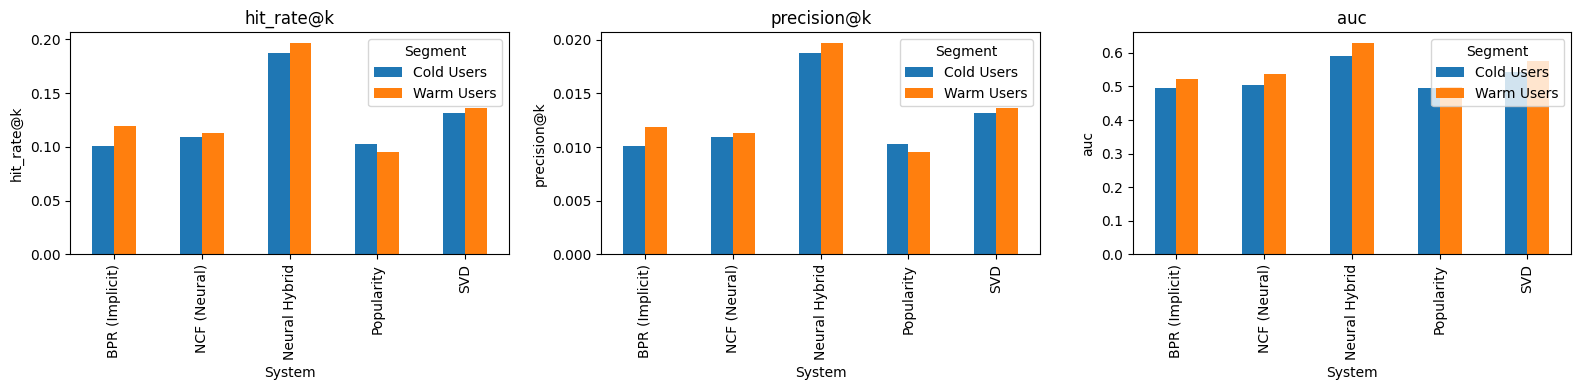

In [80]:
import matplotlib.pyplot as plt

plot_df = results_df.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ["hit_rate@k", "precision@k", "auc"]):

    pivot = plot_df.pivot(
        index="System",
        columns="Segment",
        values=metric
    )

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(title="Segment")

plt.tight_layout()
plt.show()

In [81]:
import pickle
import faiss

# 1. Movies dataframe
with open("movies.pkl", "wb") as f:
    pickle.dump(df, f)

# 2. Content embeddings
with open("embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)

# 3. Collaborative filtering model
with open("cf_model.pkl", "wb") as f:
    pickle.dump(svd_model, f)

# 4. FAISS index
faiss.write_index(index, "movie_index.faiss")

# 5. Title -> movie_idx lookup
indices = {title.lower(): idx for title, idx in zip(df["title"], df["movie_idx"])}
with open("indices.pkl", "wb") as f:
    pickle.dump(indices, f)

print("All files saved!")

All files saved!


In [82]:
import pickle

with open("train_interaction_counts.pkl", "wb") as f:
    pickle.dump(train_interaction_counts, f)

print(f"Saved train_interaction_counts.pkl with {len(train_interaction_counts):,} users tracked")

Saved train_interaction_counts.pkl with 5,400 users tracked


In [83]:
# Sanity check
with open("train_interaction_counts.pkl", "rb") as f:
    loaded = pickle.load(f)

assert loaded == train_interaction_counts
warm_users = [u for u, c in loaded.items() if c >= MIN_INTERACTIONS_WARM]
print(f"Warm users: {len(warm_users)} out of {len(loaded)}")
assert len(warm_users) > 0
print("train_interaction_counts.pkl is valid.")

Warm users: 5217 out of 5400
train_interaction_counts.pkl is valid.
